
# Pokémon Dataset Documentation

A comprehensive Pokémon dataset sourced from the [PokeAPI](https://pokeapi.co/), containing basic attributes, battle statistics, elemental types, and generation classifications.

## Feature Description

The dataset includes the following attributes:

| Name | Type | Description |
| :--- | :--- | :--- |
| **`id`** | Integer | Unique National Pokédex number for each Pokémon. |
| **`name`** | String | Pokémon name (e.g., `bulbasaur`, `pikachu`). |
| **`height_dm`** | Integer | Pokémon height in decimeters (1 dm = 10 cm). |
| **`weight_hg`** | Integer | Pokémon weight in hectograms (1 hg = 100 grams). |
| **`base_experience`** | Integer | Base experience gained when defeating this Pokémon. |
| **`type_1`** | String | Primary elemental type (e.g., `grass`, `fire`, `water`). |
| **`type_2`** | String | Secondary elemental type. Nullable if the Pokémon has only one type. |
| **`hp`** | Integer | Base Hit Points (HP) stat. |
| **`attack`** | Integer | Base Physical Attack stat. |
| **`defense`** | Integer | Base Physical Defense stat. |
| **`special_attack`** | Integer | Base Special Attack stat. |
| **`special_defense`** | Integer | Base Special Defense stat. |
| **`speed`** | Integer | Base Speed stat. |
| **`abilities`** | String | Comma-separated list of Pokémon abilities. |
| **`generation`** | String | Pokémon generation (e.g., `generation-i`). |
| **`is_legendary`** | Boolean | Indicates whether the Pokémon is Legendary (`True`/`False`). |
| **`is_mythical`** | Boolean | Indicates whether the Pokémon is Mythical (`True`/`False`). |
| **`color`** | String | Dominant Pokémon color. |
| **`shape`** | String | Pokémon body shape classification. |
| **`capture_rate`** | Integer | Catch difficulty indicator. Higher values generally indicate easier capture. |

### Exploratory Data Analysis (EDA)

- Analyze which Pokémon generations introduced the strongest Pokémon on average.
- Identify the most common dual-type combinations.
- Explore the relationship between physical attributes and battle statistics.
- Investigate the distribution of Legendary and Mythical Pokémon across generations.

### Classification Models

- Predict `type_1` based on physical attributes such as `height_dm` and `weight_hg`.
- Classify Pokémon types using base battle statistics (`hp`, `attack`, `defense`, etc.).
- Explore different classification algorithms, including Logistic Regression, Decision Trees, and Random Forest.

### Feature Engineering

- Create a `total_stats` column by summing all base battle statistics.
- Analyze stat distributions across different Pokémon generations.
- Investigate potential power creep by comparing average base stats across generations.
- Create additional features based on Pokémon types, physical characteristics, and abilities.

## Dataset Attributes Overview

The dataset combines several categories of Pokémon information:

| Category | Features |
| :--- | :--- |
| **Identification** | `id`, `name` |
| **Physical Attributes** | `height_dm`, `weight_hg`, `color`, `shape` |
| **Battle Statistics** | `hp`, `attack`, `defense`, `special_attack`, `special_defense`, `speed` |
| **Elemental Types** | `type_1`, `type_2` |
| **Game Mechanics** | `base_experience`, `capture_rate`, `abilities` |
| **Classification** | `generation`, `is_legendary`, `is_mythical` |

## Acknowledgements

This dataset is sourced from the open [PokeAPI](https://pokeapi.co/).

Special thanks to the PokeAPI project for providing accessible Pokémon data for educational, analytical, and machine learning purposes.

---

**Data Source:** [PokeAPI](https://pokeapi.co/)

In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay


sns.set_style('whitegrid')
df = pd.read_csv('pokemon_complete_stats.csv')

In [3]:
df.shape

(1351, 20)

In [4]:
df.dtypes

,0
id,int64
name,object
height_dm,int64
weight_hg,int64
base_experience,float64
type_1,object
type_2,object
hp,int64
attack,int64
defense,int64


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1351 entries, 0 to 1350
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1351 non-null   int64  
 1   name             1351 non-null   object 
 2   height_dm        1351 non-null   int64  
 3   weight_hg        1351 non-null   int64  
 4   base_experience  1302 non-null   float64
 5   type_1           1351 non-null   object 
 6   type_2           765 non-null    object 
 7   hp               1351 non-null   int64  
 8   attack           1351 non-null   int64  
 9   defense          1351 non-null   int64  
 10  special_attack   1351 non-null   int64  
 11  special_defense  1351 non-null   int64  
 12  speed            1351 non-null   int64  
 13  abilities        1337 non-null   object 
 14  generation       1351 non-null   object 
 15  is_legendary     1351 non-null   bool   
 16  is_mythical      1351 non-null   bool   
 17  color         

In [6]:
df.head()

,id,name,height_dm,weight_hg,base_experience,type_1,type_2,hp,attack,defense,special_attack,special_defense,speed,abilities,generation,is_legendary,is_mythical,color,shape,capture_rate
0,1,bulbasaur,7,69,64.0,grass,poison,45,49,49,65,65,45,"overgrow, chlorophyll",generation-i,False,False,green,quadruped,45
1,2,ivysaur,10,130,142.0,grass,poison,60,62,63,80,80,60,"overgrow, chlorophyll",generation-i,False,False,green,quadruped,45
2,3,venusaur,20,1000,236.0,grass,poison,80,82,83,100,100,80,"overgrow, chlorophyll",generation-i,False,False,green,quadruped,45
3,4,charmander,6,85,62.0,fire,NaN,39,52,43,60,50,65,"blaze, solar-power",generation-i,False,False,red,upright,45
4,5,charmeleon,11,190,142.0,fire,NaN,58,64,58,80,65,80,"blaze, solar-power",generation-i,False,False,red,upright,45


In [7]:
df.isna().sum()

,0
id,0
name,0
height_dm,0
weight_hg,0
base_experience,49
type_1,0
type_2,586
hp,0
attack,0
defense,0


In [8]:
df['base_experience']

,base_experience
0,64.0
1,142.0
2,236.0
3,62.0
4,142.0
...,...
1346,NaN
1347,NaN
1348,NaN
1349,NaN


In [9]:
df[df['abilities'].isna()]

,id,name,height_dm,weight_hg,base_experience,type_1,type_2,hp,attack,defense,special_attack,special_defense,speed,abilities,generation,is_legendary,is_mythical,color,shape,capture_rate
1325,10301,zygarde-mega,77,6100,NaN,dragon,ground,216,70,91,216,85,100,NaN,generation-vi,True,False,green,squiggle,3
1331,10307,absol-mega-z,12,490,NaN,dark,ghost,65,154,60,75,60,151,NaN,generation-iii,False,False,white,quadruped,30
1333,10309,garchomp-mega-z,19,990,NaN,dragon,NaN,108,130,85,141,85,151,NaN,generation-iv,False,False,blue,upright,45
1334,10310,lucario-mega-z,13,494,NaN,fighting,steel,70,100,70,164,70,151,NaN,generation-iv,False,False,blue,upright,45
1335,10311,heatran-mega,28,5700,NaN,fire,steel,91,120,106,175,141,67,NaN,generation-iv,True,False,brown,quadruped,3
1336,10312,darkrai-mega,30,2400,NaN,dark,NaN,70,120,130,165,130,85,NaN,generation-iv,False,True,black,humanoid,3
1340,10316,golisopod-mega,23,1480,NaN,bug,steel,75,150,175,70,120,40,NaN,generation-vii,False,False,gray,humanoid,45
1341,10317,magearna-mega,13,2481,NaN,steel,fairy,80,125,115,170,115,95,NaN,generation-vii,False,True,gray,humanoid,3
1342,10318,magearna-original-mega,13,2481,NaN,steel,fairy,80,125,115,170,115,95,NaN,generation-vii,False,True,gray,humanoid,3
1343,10319,zeraora-mega,15,445,NaN,electric,NaN,88,157,75,147,80,153,NaN,generation-vii,False,True,yellow,humanoid,3


In [10]:
df['generation'].value_counts()

,count
generation,
generation-i,238
generation-v,185
generation-iii,167
generation-ix,149
generation-viii,133
generation-vii,131
generation-iv,129
generation-ii,115
generation-vi,104


In [11]:
# Identify the most common dual-type combinations.
df[['type_1', 'type_2']].value_counts()

type_1  type_2  
normal  flying      31
rock    flying      18
grass   poison      17
bug     flying      15
        poison      13
                    ..
poison  bug          1
normal  water        1
poison  ghost        1
steel   fighting     1
water   steel        1
Name: count, Length: 203, dtype: int64

Data Visualisation

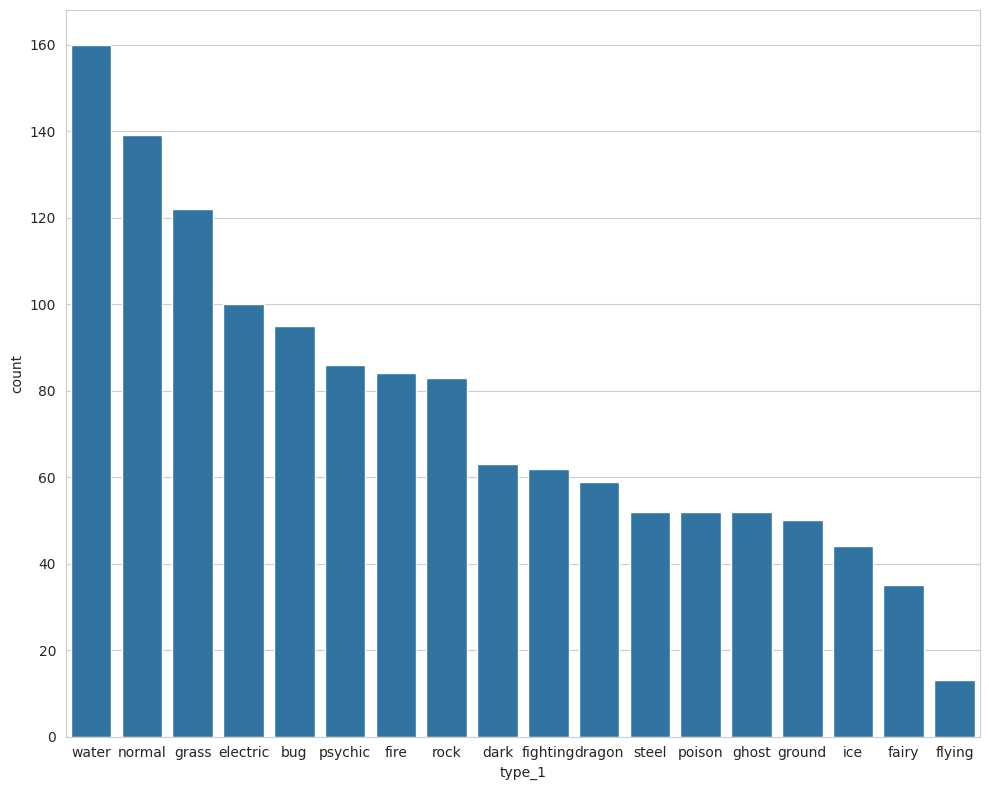

In [12]:
plt.figure(figsize=(10, 8))
sns.barplot(data=df['type_1'].value_counts())
plt.tight_layout()

In [13]:
# Investigate the distribution of Legendary and Mythical Pokémon across generations.

legend_pokemon = df[df['is_legendary']]
mythic_pokemon = df[df['is_mythical']]

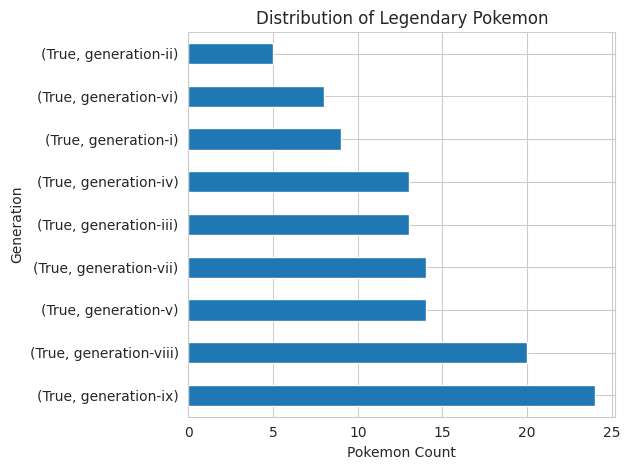

In [14]:
plt.figure()
legend_pokemon[['is_legendary','generation']].value_counts().plot(kind='barh')
plt.xlabel('Pokemon Count')
plt.ylabel('Generation')
plt.title('Distribution of Legendary Pokemon')
plt.tight_layout()
plt.show()


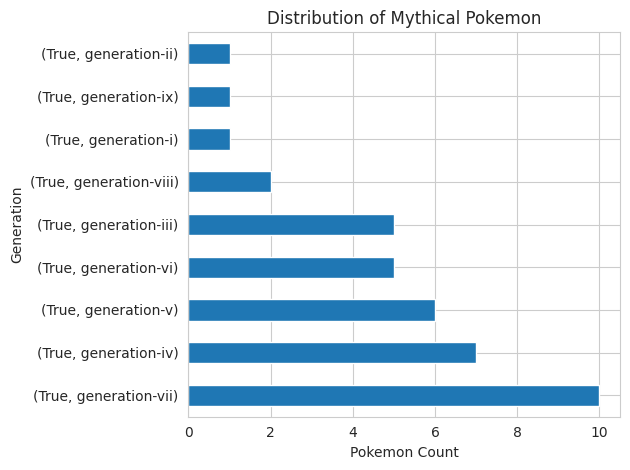

In [15]:
plt.figure()
mythic_pokemon[['is_mythical','generation']].value_counts().plot(kind='barh')
plt.xlabel('Pokemon Count')
plt.ylabel('Generation')
plt.title('Distribution of Mythical Pokemon')
plt.tight_layout()
plt.show()


Data Cleaning and Preprocessing

In [90]:
# Check missing values in the dataframe
missing_values = df.isnull().sum()
print('Missing values in each column:')
print(missing_values)

Missing values in each column:
id                   0
name                 0
height_dm            0
weight_hg            0
base_experience     49
type_1               0
type_2             586
hp                   0
attack               0
defense              0
special_attack       0
special_defense      0
speed                0
abilities           14
generation           0
is_legendary         0
is_mythical          0
color                0
shape                0
capture_rate         0
dtype: int64


In [91]:
# Handling missing values:

# get the numeric and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns

# For numeric columns, we impute missing values with the median;
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# for categorical columns, we fill missing entries with 'Missing'.
df[categorical_cols] = df[categorical_cols].fillna('Missing')

print('\nAfter imputation, missing values:')
print(df.isnull().sum())


After imputation, missing values:
id                 0
name               0
height_dm          0
weight_hg          0
base_experience    0
type_1             0
type_2             0
hp                 0
attack             0
defense            0
special_attack     0
special_defense    0
speed              0
abilities          0
generation         0
is_legendary       0
is_mythical        0
color              0
shape              0
capture_rate       0
dtype: int64


In [122]:
df['is_legendary'].value_counts()

,count
is_legendary,
False,1231
True,120


In [115]:
feature_cols = ['height_dm', 'weight_hg', 'base_experience', 'hp',
                'attack', 'defense', 'special_attack', 'special_defense', 'speed', 'capture_rate']
X = df[feature_cols]
y = df['is_legendary']

In [116]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [117]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

# Model Evaluation

In [118]:
lr.score(X_test, y_test)

0.9520295202952029

In [123]:
y_preds = lr.predict(X_test)

In [126]:
# Show the classification report (precission, recall, f1-score)
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

       False       0.96      0.99      0.97       251
        True       0.82      0.45      0.58        20

    accuracy                           0.95       271
   macro avg       0.89      0.72      0.78       271
weighted avg       0.95      0.95      0.95       271



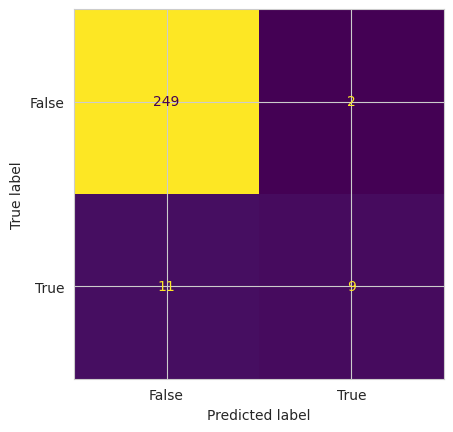

In [131]:
# Display Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_preds, colorbar=False)

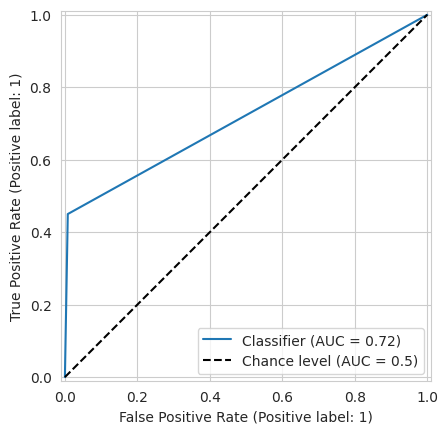

In [133]:
# Display ROC Curve
RocCurveDisplay.from_predictions(y_test, y_preds,plot_chance_level=True)